# Santander Cycles Station Segmentation using K-Means for Rebalancing and Capacity Planning

## Project Overview
This project uses recent Santander Cycles trip data from Transport for London (TfL) to segment docking stations based on operational usage behaviour. The objective is to identify station types with similar demand patterns and imbalance behaviour so that bike-sharing operations can be better informed for rebalancing and capacity planning.

## Business Problem
In a bike-sharing system, stations do not behave in the same way. Some stations experience heavy morning departures, some receive more bikes than they send, and others are more active during weekends or evening periods. These differences can lead to operational issues such as stations running out of bikes or running out of empty docks.

## Project Objective
The goal of this project is to use K-Means clustering to group Santander Cycles stations based on their behavioural and operational characteristics. The final clusters are intended to support:
- station profiling
- rebalancing prioritisation
- demand pattern understanding
- operational planning

## Dataset
The analysis uses official Santander Cycles journey data from TfL. For this project, a recent August 2025 subset was selected to keep the workflow manageable while still capturing realistic and recent station behaviour.

## Data Used
The notebook combines the following journey extracts:
- 01 Aug 2025 to 15 Aug 2025
- 16 Aug 2025 to 31 Aug 2025

Each row in the raw dataset represents one cycle journey and includes start station, end station, timestamps, bike type, and trip duration information.

In [1]:
import pandas as pd

# Load and Combine Journey Data
# The two August 2025 journey extracts are loaded and combined into one DataFrame so that station behaviour can be analysed across the full month.

df1 = pd.read_csv("425JourneyDataExtract01Aug2025-15Aug2025.csv")
df2 = pd.read_csv("426JourneyDataExtract16Aug2025-31Aug2025.csv")

# Combine
df = pd.concat([df1, df2], ignore_index=True)

# Basic inspection
print("Shape:", df.shape)

Shape: (804945, 11)


### Initial Inspection Summary
The raw dataset contains individual Santander Cycles journeys with station, datetime, bike model, and duration information. At this stage, the data is still at journey level, so further processing is required before clustering can be performed at station level.

In [2]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Number', 'Start date', 'Start station', 'Start station number', 'End date', 'End station', 'End station number', 'Bike number', 'Bike model', 'Total duration', 'Total duration (ms)']


In [3]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
      Number        Start date                    Start station  \
0  151301320  2025-08-15 23:59  Duke Street Hill, London Bridge   
1  151301321  2025-08-15 23:59             Wardour Street, Soho   
2  151301322  2025-08-15 23:59   Westferry Circus, Canary Wharf   
3  151301323  2025-08-15 23:59      Maplin Street, Mile End_OLD   
4  151301324  2025-08-15 23:59  Duke Street Hill, London Bridge   

   Start station number          End date                     End station  \
0                300083  2025-08-16 01:10     Putney Rail Station, Putney   
1                  1163  2025-08-16 00:20  Northdown Street, King's Cross   
2                300228  2025-08-16 00:21  Westferry Circus, Canary Wharf   
3             200230444  2025-08-16 00:01            Merchant Street, Bow   
4                300083  2025-08-16 01:10     Putney Rail Station, Putney   

   End station number  Bike number  Bike model Total duration  \
0            300033.0        63101  PBSC_EBIKE     1h 

## Missing Values and Data Types
Before feature engineering, the dataset is checked for missing values and data types to identify any issues that may affect preprocessing.

In [4]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Number                   0
Start date               0
Start station            0
Start station number     0
End date                53
End station             53
End station number      53
Bike number              0
Bike model               0
Total duration          53
Total duration (ms)     53
dtype: int64


### Inspection Findings
Only a very small number of rows contain missing values in end-side journey information. Since these rows represent a negligible proportion of the dataset and contain incomplete trip outcomes, they are removed rather than imputed. Imputation would create artificial end-station behaviour, which would weaken the validity of the station-level analysis.

In [5]:
print("\nData types:")
print(df.dtypes)


Data types:
Number                    int64
Start date               object
Start station            object
Start station number      int64
End date                 object
End station              object
End station number      float64
Bike number               int64
Bike model               object
Total duration           object
Total duration (ms)     float64
dtype: object


## Clean Column Names
Column names are standardised to lower case and underscore format to make later processing cleaner and less error-prone.

In [6]:
# Cleaning the column names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print(df.columns.tolist())

['number', 'start_date', 'start_station', 'start_station_number', 'end_date', 'end_station', 'end_station_number', 'bike_number', 'bike_model', 'total_duration', 'total_duration_ms']


## Validate Trip Identifiers and Convert Date Columns
The `number` column is checked to confirm whether it behaves as a unique journey identifier. The date columns are then converted to datetime format so that time-based features such as hour, weekday, and weekend flags can be created.

In [7]:
# check trip ID uniqueness

print("Total rows:", len(df))
print("Unique trip IDs:", df["number"].nunique())
print("Duplicate trip IDs:", df["number"].duplicated().sum())

Total rows: 804945
Unique trip IDs: 804945
Duplicate trip IDs: 0


In [8]:
# It converts, start_date and end_date from plain text into real datetime format


df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce")

print(df[["start_date", "end_date"]].dtypes)
print(df[["start_date", "end_date"]].isnull().sum())
print(df[["start_date", "end_date"]].head())

start_date    datetime64[ns]
end_date      datetime64[ns]
dtype: object
start_date     0
end_date      53
dtype: int64
           start_date            end_date
0 2025-08-15 23:59:00 2025-08-16 01:10:00
1 2025-08-15 23:59:00 2025-08-16 00:20:00
2 2025-08-15 23:59:00 2025-08-16 00:21:00
3 2025-08-15 23:59:00 2025-08-16 00:01:00
4 2025-08-15 23:59:00 2025-08-16 01:10:00


### Validation Summary
The `number` field behaves as a unique journey identifier, confirming that each row represents one journey. The start and end timestamps were successfully converted to datetime format, which allows the notebook to derive useful temporal station-behaviour features.

## Remove Incomplete Journey Records
Rows with missing end-side journey information are removed because the project depends on reliable origin-destination station behaviour. The number of removed rows is extremely small relative to the full dataset, so this cleaning step does not materially affect the analysis.

In [9]:
#  droping the tiny number of incomplete rows

df = df.dropna(subset=["end_date", "end_station", "end_station_number", "total_duration_ms"]).copy()

print("Shape after dropping incomplete rows:", df.shape)
print(df.isnull().sum())

Shape after dropping incomplete rows: (804892, 11)
number                  0
start_date              0
start_station           0
start_station_number    0
end_date                0
end_station             0
end_station_number      0
bike_number             0
bike_model              0
total_duration          0
total_duration_ms       0
dtype: int64


## Create Time-Based Features
Since clustering is intended to capture station behaviour, the notebook derives several temporal features from the journey start time, including:
- journey date
- departure hour
- day of week
- weekend flag
- morning peak flag
- evening peak flag

These variables help translate raw trip timestamps into interpretable behavioural patterns.

In [10]:
#  time-based features

df["journey_date"] = df["start_date"].dt.date
df["start_hour"] = df["start_date"].dt.hour
df["day_of_week_num"] = df["start_date"].dt.dayofweek
df["day_of_week"] = df["start_date"].dt.day_name()
df["is_weekend"] = df["day_of_week_num"] >= 5

print(df[["start_date", "journey_date", "start_hour", "day_of_week", "is_weekend"]].head())

           start_date journey_date  start_hour day_of_week  is_weekend
0 2025-08-15 23:59:00   2025-08-15          23      Friday       False
1 2025-08-15 23:59:00   2025-08-15          23      Friday       False
2 2025-08-15 23:59:00   2025-08-15          23      Friday       False
3 2025-08-15 23:59:00   2025-08-15          23      Friday       False
4 2025-08-15 23:59:00   2025-08-15          23      Friday       False


### Temporal Feature Summary
The dataset now contains time-based indicators that allow stations to be compared by departure timing, weekend usage, and peak-period behaviour. These features are important because raw timestamps alone are not suitable inputs for clustering.

In [11]:
print(df[["start_hour", "day_of_week", "is_weekend"]].describe(include="all"))

           start_hour day_of_week is_weekend
count   804892.000000      804892     804892
unique            NaN           7          2
top               NaN      Sunday      False
freq              NaN      138268     549200
mean        14.147385         NaN        NaN
std          4.887506         NaN        NaN
min          0.000000         NaN        NaN
25%         10.000000         NaN        NaN
50%         15.000000         NaN        NaN
75%         18.000000         NaN        NaN
max         23.000000         NaN        NaN


In [12]:
# peak-hour flags

df["is_morning_peak"] = df["start_hour"].between(7, 9)
df["is_evening_peak"] = df["start_hour"].between(17, 19)

print(df[["start_hour", "is_morning_peak", "is_evening_peak"]].head(10))
print(df[["is_morning_peak", "is_evening_peak"]].mean())

   start_hour  is_morning_peak  is_evening_peak
0          23            False            False
1          23            False            False
2          23            False            False
3          23            False            False
4          23            False            False
5          23            False            False
6          23            False            False
7          23            False            False
8           0            False            False
9          23            False            False
is_morning_peak    0.170509
is_evening_peak    0.264274
dtype: float64


is_morning_peak = 0.170509
meaning about 17.1% of trips started during the morning peak window
is_evening_peak = 0.264274
meaning about 26.4% of trips started during the evening peak window

More trips start in your evening peak window than in your morning peak window

## Inspect Bike Model Distribution
Bike model usage is briefly explored to understand the mix of classic bikes and e-bikes in the selected period. This may support future feature expansion, such as station-level e-bike share.

In [13]:
# inspect bike model distribution

print(df["bike_model"].value_counts(dropna=False))
print(df["bike_model"].value_counts(normalize=True, dropna=False))

bike_model
CLASSIC       654303
PBSC_EBIKE    150589
Name: count, dtype: int64
bike_model
CLASSIC       0.812908
PBSC_EBIKE    0.187092
Name: proportion, dtype: float64


### Bike Model Summary
Most journeys in the selected August 2025 period were made using classic bikes, while a smaller but meaningful proportion used e-bikes. This confirms that station demand is not limited to a single bike type and may support future operational analysis.

## Build Departure-Side Station Features
The raw journey-level data is aggregated to the station level using start-station information. This produces departure-based behavioural features such as:
- total departures
- average daily departures
- weekend departure share
- morning peak departure share
- evening peak departure share
- average trip duration from the station

At this stage, each row represents one station as a trip origin.

In [14]:
# departure-based station features

departures = (
    df.groupby(["start_station_number", "start_station"])
      .agg(
          total_departures=("number", "count"),
          active_days=("journey_date", "nunique"),
          weekday_departures=("is_weekend", lambda x: (~x).sum()),
          weekend_departures=("is_weekend", "sum"),
          morning_peak_departures=("is_morning_peak", "sum"),
          evening_peak_departures=("is_evening_peak", "sum"),
          avg_departure_duration_ms=("total_duration_ms", "mean")
      )
      .reset_index()
)

departures["avg_daily_departures"] = departures["total_departures"] / departures["active_days"]
departures["weekend_departure_share"] = departures["weekend_departures"] / departures["total_departures"]
departures["morning_peak_departure_share"] = departures["morning_peak_departures"] / departures["total_departures"]
departures["evening_peak_departure_share"] = departures["evening_peak_departures"] / departures["total_departures"]

print(departures.head())
print(departures.shape)

   start_station_number                start_station  total_departures  \
0                   959      Milroy Walk, South Bank               747   
1                   960    Hop Exchange, The Borough              3552   
2                   961    Union Street, The Borough               995   
3                   962  Stamford Street, South Bank               726   
4                   963       Bankside Mix, Bankside              1017   

   active_days  weekday_departures  weekend_departures  \
0           30                 528                 219   
1           30                2385                1167   
2           30                 721                 274   
3           30                 507                 219   
4           30                 718                 299   

   morning_peak_departures  evening_peak_departures  \
0                       80                      259   
1                      335                      863   
2                      212               

### Departure Feature Summary
The departure-side table captures how each station behaves as an origin point in the network. This converts the data from journey level to station-behaviour level, which is the correct unit of analysis for clustering.

## Build Arrival-Side Station Features
A separate station-level table is created using end-station information. This captures how frequently each station behaves as a destination and provides average daily arrival volume.

In [15]:
# arrival-based station features

arrivals = (
    df.groupby(["end_station_number", "end_station"])
      .agg(
          total_arrivals=("number", "count"),
          active_days_arr=("journey_date", "nunique")
      )
      .reset_index()
)

arrivals["avg_daily_arrivals"] = arrivals["total_arrivals"] / arrivals["active_days_arr"]

print(arrivals.head())
print(arrivals.shape)

   end_station_number                  end_station  total_arrivals  \
0               959.0      Milroy Walk, South Bank             784   
1               960.0    Hop Exchange, The Borough            4479   
2               961.0    Union Street, The Borough            1003   
3               962.0  Stamford Street, South Bank             809   
4               963.0       Bankside Mix, Bankside            1151   

   active_days_arr  avg_daily_arrivals  
0               30           26.133333  
1               30          149.300000  
2               30           33.433333  
3               30           26.966667  
4               31           37.129032  
(806, 5)


### Arrival Feature Summary
The arrival-side table complements the departure-side table by showing how stations behave as trip destinations. Both views are required to understand full station behaviour.

## Merge Departure and Arrival Station Features
The departure-side and arrival-side station summaries are merged so that each station has a combined operational profile. An outer merge is used to retain all stations, including those that appear only on one side during the selected period.

The merged table is then cleaned by creating one final station identifier and one final station name column, while keeping the behavioural features from both sides.

In [16]:
# merge departures and arrivals

station_features = departures.merge(
    arrivals,
    left_on="start_station_number",
    right_on="end_station_number",
    how="outer"
)

print(station_features.head())

   start_station_number                start_station  total_departures  \
0                 959.0      Milroy Walk, South Bank             747.0   
1                 960.0    Hop Exchange, The Borough            3552.0   
2                 961.0    Union Street, The Borough             995.0   
3                 962.0  Stamford Street, South Bank             726.0   
4                 963.0       Bankside Mix, Bankside            1017.0   

   active_days  weekday_departures  weekend_departures  \
0         30.0               528.0               219.0   
1         30.0              2385.0              1167.0   
2         30.0               721.0               274.0   
3         30.0               507.0               219.0   
4         30.0               718.0               299.0   

   morning_peak_departures  evening_peak_departures  \
0                     80.0                    259.0   
1                    335.0                    863.0   
2                    212.0               

### Merged Station Table Summary
The station-level modelling table now contains one row per station and combines both departure and arrival behaviour. This is the main analytical dataset that will be used for clustering.

In [17]:
print(station_features.shape)
print(station_features.columns.tolist())

(806, 18)
['start_station_number', 'start_station', 'total_departures', 'active_days', 'weekday_departures', 'weekend_departures', 'morning_peak_departures', 'evening_peak_departures', 'avg_departure_duration_ms', 'avg_daily_departures', 'weekend_departure_share', 'morning_peak_departure_share', 'evening_peak_departure_share', 'end_station_number', 'end_station', 'total_arrivals', 'active_days_arr', 'avg_daily_arrivals']


In [18]:
# clean the merged table

station_features["station_number"] = station_features["start_station_number"].fillna(station_features["end_station_number"])
station_features["station_name"] = station_features["start_station"].fillna(station_features["end_station"])

station_features = station_features[
    [
        "station_number",
        "station_name",
        "total_departures",
        "active_days",
        "weekday_departures",
        "weekend_departures",
        "morning_peak_departures",
        "evening_peak_departures",
        "avg_departure_duration_ms",
        "avg_daily_departures",
        "weekend_departure_share",
        "morning_peak_departure_share",
        "evening_peak_departure_share",
        "total_arrivals",
        "active_days_arr",
        "avg_daily_arrivals"
    ]
].copy()

station_features = station_features.fillna(0)

print(station_features.head())
print(station_features.shape)
print(station_features.isnull().sum())

   station_number                 station_name  total_departures  active_days  \
0           959.0      Milroy Walk, South Bank             747.0         30.0   
1           960.0    Hop Exchange, The Borough            3552.0         30.0   
2           961.0    Union Street, The Borough             995.0         30.0   
3           962.0  Stamford Street, South Bank             726.0         30.0   
4           963.0       Bankside Mix, Bankside            1017.0         30.0   

   weekday_departures  weekend_departures  morning_peak_departures  \
0               528.0               219.0                     80.0   
1              2385.0              1167.0                    335.0   
2               721.0               274.0                    212.0   
3               507.0               219.0                    193.0   
4               718.0               299.0                    113.0   

   evening_peak_departures  avg_departure_duration_ms  avg_daily_departures  \
0            

## Create Operational Imbalance Features
Two additional features are created to capture station imbalance:

- **Net flow**: total arrivals minus total departures
- **Imbalance ratio**: the relative size of the arrival-departure difference

These variables are important because station imbalance is directly related to rebalancing needs in a bike-sharing network.

In [19]:
# create imbalance features

station_features["net_flow"] = station_features["total_arrivals"] - station_features["total_departures"]

station_features["imbalance_ratio"] = (
    (station_features["total_arrivals"] - station_features["total_departures"]).abs()
    / (station_features["total_arrivals"] + station_features["total_departures"] + 1)
)

print(station_features.head())

   station_number                 station_name  total_departures  active_days  \
0           959.0      Milroy Walk, South Bank             747.0         30.0   
1           960.0    Hop Exchange, The Borough            3552.0         30.0   
2           961.0    Union Street, The Borough             995.0         30.0   
3           962.0  Stamford Street, South Bank             726.0         30.0   
4           963.0       Bankside Mix, Bankside            1017.0         30.0   

   weekday_departures  weekend_departures  morning_peak_departures  \
0               528.0               219.0                     80.0   
1              2385.0              1167.0                    335.0   
2               721.0               274.0                    212.0   
3               507.0               219.0                    193.0   
4               718.0               299.0                    113.0   

   evening_peak_departures  avg_departure_duration_ms  avg_daily_departures  \
0            

In [20]:
# inspect important stations

print("Number of stations:", station_features.shape[0])

print("\nTop 10 by departures:")
print(
    station_features.sort_values("total_departures", ascending=False)[
        ["station_name", "total_departures", "total_arrivals", "net_flow", "imbalance_ratio"]
    ].head(10)
)

Number of stations: 806

Top 10 by departures:
                            station_name  total_departures  total_arrivals  \
111          Hyde Park Corner, Hyde Park            8398.0            7382   
166               Albert Gate, Hyde Park            5410.0            5004   
190  Black Lion Gate, Kensington Gardens            4732.0            4719   
108         Waterloo Station 3, Waterloo            3942.0            3527   
1              Hop Exchange, The Borough            3552.0            4479   
124         Triangle Car Park, Hyde Park            3533.0            3514   
295         Waterloo Station 1, Waterloo            3522.0            3328   
245       Serpentine Car Park, Hyde Park            3381.0            3385   
50            Argyle Street, Kings Cross            3228.0            2854   
796        Westminster Pier, Westminster            3216.0            3257   

     net_flow  imbalance_ratio  
111   -1016.0         0.064381  
166    -406.0         0.0389

### Operational Interpretation
The busiest stations are not all operationally identical. Some high-volume stations remain relatively balanced, while others show clear net inflow or net outflow behaviour. This supports the logic of clustering stations based on operational patterns rather than relying on simple volume alone.

## select the clustering features

In [21]:
cluster_features = station_features[
    [
        "avg_daily_departures",
        "avg_daily_arrivals",
        "weekend_departure_share",
        "morning_peak_departure_share",
        "evening_peak_departure_share",
        "avg_departure_duration_ms",
        "imbalance_ratio"
    ]
].copy()

print(cluster_features.head())
print(cluster_features.shape)

   avg_daily_departures  avg_daily_arrivals  weekend_departure_share  \
0             24.900000           26.133333                 0.293173   
1            118.400000          149.300000                 0.328547   
2             33.166667           33.433333                 0.275377   
3             24.200000           26.966667                 0.301653   
4             33.900000           37.129032                 0.294002   

   morning_peak_departure_share  evening_peak_departure_share  \
0                      0.107095                      0.346720   
1                      0.094313                      0.242962   
2                      0.213065                      0.260302   
3                      0.265840                      0.225895   
4                      0.111111                      0.352999   

   avg_departure_duration_ms  imbalance_ratio  
0               9.796887e+05         0.024151  
1               1.691872e+06         0.115413  
2               9.294264e+05    

In [22]:
print(cluster_features.describe())

       avg_daily_departures  avg_daily_arrivals  weekend_departure_share  \
count            806.000000          806.000000               806.000000   
mean              33.257955           33.231131                 0.314139   
std               21.728755           21.923368                 0.075703   
min                0.000000            1.545455                 0.000000   
25%               20.123387           19.866667                 0.277375   
50%               28.819355           28.129032                 0.318537   
75%               40.306452           39.451613                 0.356988   
max              270.903226          238.129032                 0.598897   

       morning_peak_departure_share  evening_peak_departure_share  \
count                    806.000000                    806.000000   
mean                       0.182389                      0.255702   
std                        0.093322                      0.084942   
min                        0.000000    

### Feature Scaling

In [23]:
# standardise the features (scaling)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

print(X_scaled.shape)
print(X_scaled[:5])

(806, 7)
[[-3.84888349e-01 -3.23955917e-01 -2.77133283e-01 -8.07316505e-01
   1.07220834e+00 -4.32720204e-01 -8.53114179e-02]
 [ 3.92083734e+00  5.29758643e+00  1.90440928e-01 -9.44368214e-01
  -1.50076391e-01 -1.80887151e-01  1.44009175e+00]
 [-4.20386689e-03  9.22886574e-03 -5.12354559e-01  3.28924013e-01
   5.41880031e-02 -4.50493273e-01 -4.22100467e-01]
 [-4.17123728e-01 -2.85921125e-01 -1.65043734e-01  8.94789959e-01
  -3.51120096e-01 -3.83512720e-01  4.14203740e-01]
 [ 2.95665307e-02  1.77907036e-01 -2.66172087e-01 -7.64255234e-01
   1.14617321e+00 -2.04891692e-01  5.43627355e-01]]


### Elbow method for the cluster selection

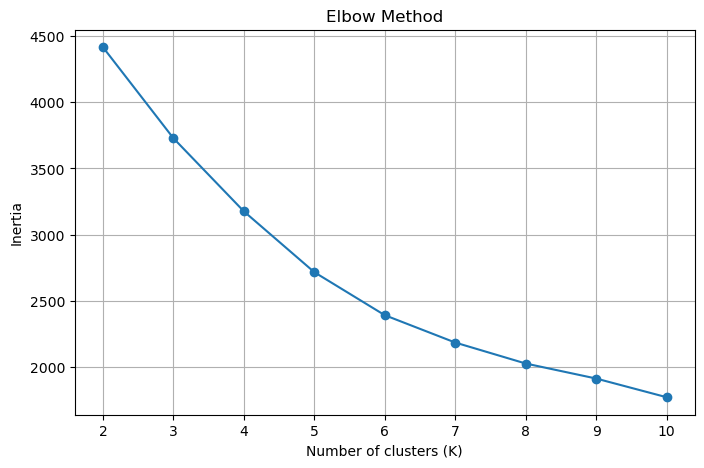

In [24]:
# Elbow method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

### Silhouette score method for cluster selection

In [25]:
# silhouette

from sklearn.metrics import silhouette_score

sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

for k, score in zip(k_values, sil_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3104
K = 3, Silhouette Score = 0.3334
K = 4, Silhouette Score = 0.3242
K = 5, Silhouette Score = 0.3444
K = 6, Silhouette Score = 0.2366
K = 7, Silhouette Score = 0.2132
K = 8, Silhouette Score = 0.2038
K = 9, Silhouette Score = 0.2118
K = 10, Silhouette Score = 0.1997


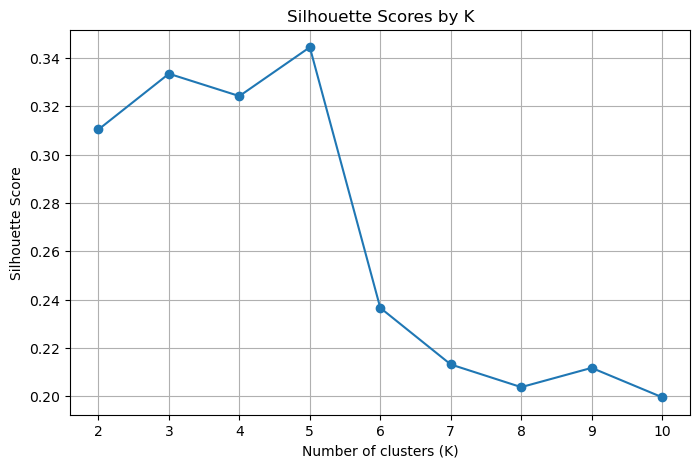

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by K")
plt.grid(True)
plt.show()

## Select the Final Value of K

The final value of **K = 5** was selected using both the elbow method and silhouette score.

### Reason for Selection
- The elbow plot showed that inertia continued to decrease with increasing K, but the rate of improvement started to slow around **K = 5**
- The silhouette score was **highest at K = 5**, indicating the strongest balance between cluster cohesion and separation
- Values above 5 showed a clear decline in silhouette score, suggesting weaker clustering quality

### Final Decision
Based on both clustering diagnostics and practical interpretability, **K = 5** was chosen as the final number of clusters for the station segmentation analysis.

## Fit the Final K-Means Model

After selecting **K = 5**, the final K-Means model is fitted to the standardised station feature set. The resulting cluster label for each station is then added back to the main station-level DataFrame so that station names, operational features, and cluster membership can be analysed together.

In [27]:
# fit final K-Means model

final_k = 5

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
station_features["cluster"] = kmeans.fit_predict(X_scaled)

print(station_features[["station_name", "cluster"]].head())
print("\nCluster sizes:")
print(station_features["cluster"].value_counts().sort_index())

                  station_name  cluster
0      Milroy Walk, South Bank        4
1    Hop Exchange, The Borough        1
2    Union Street, The Borough        2
3  Stamford Street, South Bank        2
4       Bankside Mix, Bankside        4

Cluster sizes:
cluster
0     22
1     95
2    513
3      2
4    174
Name: count, dtype: int64


### Cluster Size Summary

The final K-Means model produced five station clusters of unequal size. This suggests that station behaviour in the Santander Cycles network is not evenly distributed across a few balanced groups. Instead, most stations appear to follow one dominant operational pattern, while smaller groups represent more specific or unusual station behaviours.

In particular:
- one cluster contains the majority of stations and likely represents the most common station type
- smaller clusters capture more specialised behaviour patterns
- one very small cluster appears to represent non-standard or operationally unusual stations

## Profile the Station Clusters

To understand what each cluster represents, the mean station-level features are calculated within each cluster. This helps translate the clustering output into operational station types by comparing activity level, timing behaviour, trip duration, and imbalance characteristics.

In [28]:
# Cluster Profiling

cluster_profile = station_features.groupby("cluster")[
    [
        "avg_daily_departures",
        "avg_daily_arrivals",
        "weekend_departure_share",
        "morning_peak_departure_share",
        "evening_peak_departure_share",
        "avg_departure_duration_ms",
        "imbalance_ratio",
        "net_flow"
    ]
].mean()

print(cluster_profile)

         avg_daily_departures  avg_daily_arrivals  weekend_departure_share  \
cluster                                                                      
0                   26.356479           25.863148                 0.377603   
1                   75.340509           76.386848                 0.339006   
2                   26.666500           25.839273                 0.331938   
3                    0.000000            3.041958                 0.000000   
4                   30.970151           32.740925                 0.243676   

         morning_peak_departure_share  evening_peak_departure_share  \
cluster                                                               
0                            0.180782                      0.241875   
1                            0.119230                      0.280364   
2                            0.227563                      0.212426   
3                            0.000000                      0.000000   
4                          

### Cluster Profiling Summary

The cluster profile table shows that the five clusters differ meaningfully in terms of:
- daily station activity
- weekend orientation
- peak-period behaviour
- average trip duration
- operational imbalance

This confirms that the clustering model is not simply separating stations by one variable, but is capturing broader patterns of station behaviour across the network.

In [29]:
# Inspect actual stations in each cluster

for c in sorted(station_features["cluster"].unique()):
    print(f"\nCluster {c}")
    print(station_features[station_features["cluster"] == c][["station_name"]].head(10))


Cluster 0
                                    station_name
92              Wellington Road, St. John's Wood
127    St. John's Wood Church, The Regent's Park
299                  Fire Brigade Pier, Vauxhall
354                       Rodney Road , Walworth
399                        Millharbour, Millwall
468                Jubilee Crescent, Cubitt Town
474  Westfield Southern Terrace ,Shepherd's Bush
480               Princedale Road , Holland Park
484                        Hoxton Street, Hoxton
502                    Mudchute DLR, Cubitt Town

Cluster 1
                      station_name
1        Hop Exchange, The Borough
5          Bath Street, St. Luke's
14  Bethnal Green Road, Shoreditch
21      British Museum, Bloomsbury
30                Crosswall, Tower
34  Little Argyll Street, West End
39        Vauxhall Cross, Vauxhall
46       Drury Lane, Covent Garden
50      Argyle Street, Kings Cross
65       William IV Street, Strand

Cluster 2
                          station_name
2   

## Interpretation of the Five Station Clusters

### Cluster 0: Longer-Duration, Weekend-Leaning Moderate Stations
This cluster contains stations with moderate daily activity, relatively higher weekend share, and unusually long average trip duration. These stations appear more associated with longer recreational or localised journeys rather than typical short commuter movements.

### Cluster 1: High-Volume Central Active Stations
This cluster includes stations with high daily departures and arrivals, relatively balanced flows, and strong overall usage. These are likely major central stations or high-traffic urban hubs that serve a broad mix of travel demand.

### Cluster 2: Standard Everyday Commuter-Type Stations
This is the largest cluster and appears to represent the most typical station pattern in the network. Stations in this group show moderate activity, fairly balanced flows, and relatively stronger morning peak behaviour. This suggests regular day-to-day urban and commuter-oriented use.

### Cluster 3: Special Operational or Anomalous Stations
This very small cluster contains stations with highly unusual behaviour, including almost no recorded departures and extremely high imbalance. Based on the station names, this cluster appears to capture workshop or operational stations rather than standard public-use docking stations.

### Cluster 4: Evening-Oriented Central Destination Stations
Stations in this cluster show moderate activity, lower weekend share, and a strong evening peak pattern. These stations appear more likely to behave as destination or return points later in the day, particularly in central mixed-use areas.

## Operational Recommendations

The clustering results are useful only if they lead to operational actions. Based on the identified station types, the following actions are recommended:

- **Cluster 0**: monitor weekend demand and maintain availability during leisure-heavy periods
- **Cluster 1**: treat as high-priority core stations for monitoring and possible capacity review
- **Cluster 2**: manage using standard commuter-period rebalancing rules
- **Cluster 3**: treat as non-standard operational stations and exclude from normal public-station planning
- **Cluster 4**: prioritise evening dock relief and destination-side balancing

This converts the clustering output into a practical station-management framework rather than a purely descriptive analysis.

In [34]:
action_map = {
    0: "Monitor weekend demand and leisure-period availability",
    1: "High-priority core station for monitoring and capacity review",
    2: "Standard commuter-period rebalancing",
    3: "Non-standard operational station; exclude from normal public planning",
    4: "Prioritise evening dock relief and destination-side balancing"
}

station_features["recommended_action"] = station_features["cluster"].map(action_map)

print(station_features[["station_name", "cluster", "recommended_action"]].head(10))

                  station_name  cluster  \
0      Milroy Walk, South Bank        4   
1    Hop Exchange, The Borough        1   
2    Union Street, The Borough        2   
3  Stamford Street, South Bank        2   
4       Bankside Mix, Bankside        4   
5      Bath Street, St. Luke's        1   
6   Tachbrook Street, Victoria        2   
7   New Kent Road, The Borough        2   
8        Golden Lane, Barbican        4   
9     Warwick Row, Westminster        4   

                                  recommended_action  
0  Prioritise evening dock relief and destination...  
1  High-priority core station for monitoring and ...  
2               Standard commuter-period rebalancing  
3               Standard commuter-period rebalancing  
4  Prioritise evening dock relief and destination...  
5  High-priority core station for monitoring and ...  
6               Standard commuter-period rebalancing  
7               Standard commuter-period rebalancing  
8  Prioritise evening dock reli

In [35]:
action_summary = (
    station_features.groupby("cluster")[["station_name"]]
    .count()
    .rename(columns={"station_name": "station_count"})
)

action_summary["recommended_action"] = action_summary.index.map(action_map)
print(action_summary)

         station_count                                 recommended_action
cluster                                                                  
0                   22  Monitor weekend demand and leisure-period avai...
1                   95  High-priority core station for monitoring and ...
2                  513               Standard commuter-period rebalancing
3                    2  Non-standard operational station; exclude from...
4                  174  Prioritise evening dock relief and destination...


### Action Framework Summary

The cluster labels are now linked to recommended operational actions. This makes the project more practical by showing how the station groups could support rebalancing and capacity planning decisions.

## Visualise the Clusters using PCA

Principal Component Analysis (PCA) is used here only for two-dimensional visualisation. The clustering itself was performed on the full scaled feature set, while PCA provides a simplified 2D view of how the station groups are distributed in feature space.

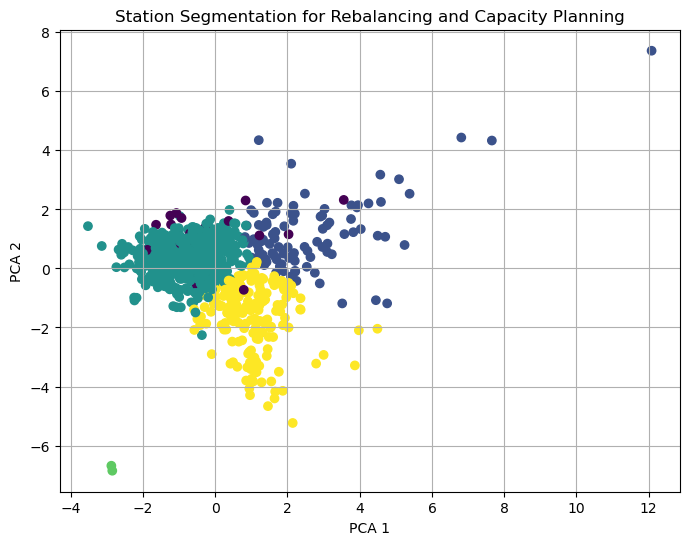

In [36]:
# PCA visualisation

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

station_features["pca1"] = X_pca[:, 0]
station_features["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    station_features["pca1"],
    station_features["pca2"],
    c=station_features["cluster"]
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Station Segmentation for Rebalancing and Capacity Planning")
plt.grid(True)
plt.show()

### PCA Visualisation Summary

The PCA plot shows that the station clusters are not completely overlapping, which supports the usefulness of the final clustering solution. One large cluster dominates the central region of the plot, while smaller clusters occupy more distinct areas. A very small group of stations appears clearly separated from the rest, which is consistent with the earlier interpretation of an anomalous or operational-use cluster.

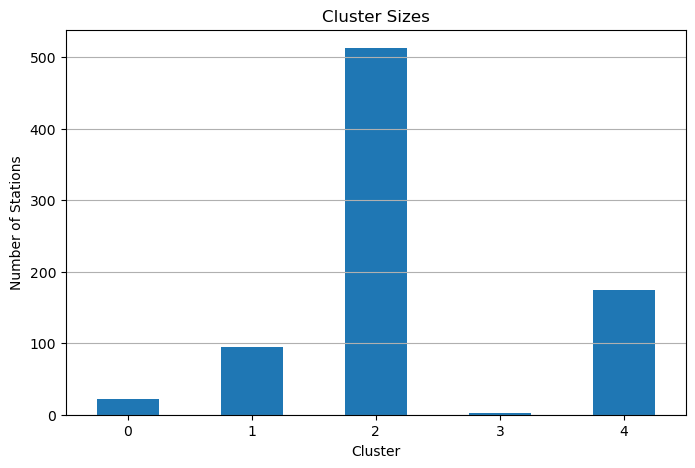

In [32]:
import matplotlib.pyplot as plt

cluster_sizes = station_features["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_sizes.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of Stations")
plt.title("Cluster Sizes")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

### Cluster Size Interpretation
The cluster size distribution shows that station behaviour is uneven across the network. Most stations belong to one dominant behaviour group, while a smaller number fall into more specialised operational categories. This is realistic in a transport network, where common station patterns usually coexist with a few unique or extreme cases.

## Final Conclusion

This project used recent Santander Cycles journey data from August 2025 to build station-level behavioural profiles and segment stations using K-Means clustering.

The workflow moved from raw journey records to a structured station-level dataset by:
- cleaning and validating the trip data
- creating temporal features
- aggregating departure and arrival behaviour
- deriving operational imbalance measures
- selecting meaningful station behaviour features for clustering

The final K-Means solution with **K = 5** identified five distinct station behaviour groups. These included:
- longer-duration, weekend-leaning stations
- high-volume central active stations
- standard everyday commuter-style stations
- special operational or anomalous stations
- evening-oriented central destination stations

Overall, the results show that Santander Cycles stations do not behave uniformly. Instead, stations differ in meaningful ways across demand level, timing structure, duration profile, and imbalance behaviour. These findings can support practical decisions related to station monitoring, bike rebalancing, and capacity planning.

## Limitations

This analysis is based on one recent monthly period, so the results may not fully represent seasonal or annual station behaviour across the network. In addition, K-Means assumes relatively compact cluster structure and may not capture more complex non-linear station relationships. The final clustering also depends on the selected feature set, so alternative feature engineering choices could produce somewhat different station groupings.

Another important limitation is that the analysis focuses on behavioural station summaries rather than live dock availability or real-time rebalancing events. As a result, the project identifies useful operational station types, but it does not directly model day-by-day rebalancing decisions.

## Future Improvements

Possible extensions of this project include:
- analysing multiple months or seasonal periods
- adding station metadata such as location, zone, or docking capacity
- incorporating station-level e-bike usage share
- comparing K-Means with Agglomerative Clustering or DBSCAN
- creating a station priority score for rebalancing support
- linking cluster results to live station availability data for operational monitoring